
🔍 Loading: rest_off_sub-01_c_ieeg.npz
✓ Loaded 6 channels
  Subject: sub-01, Trial: c
  Duration: 60.0s, sfreq: 250.0 Hz
  Channels: ['STN-L', 'ECOG-8-9-R', 'ECOG-10-11-R', 'ECOG-10-11-L', 'ECOG-8-9-L', 'STN-R']

📈 Plotting raw trace (first 10s)...


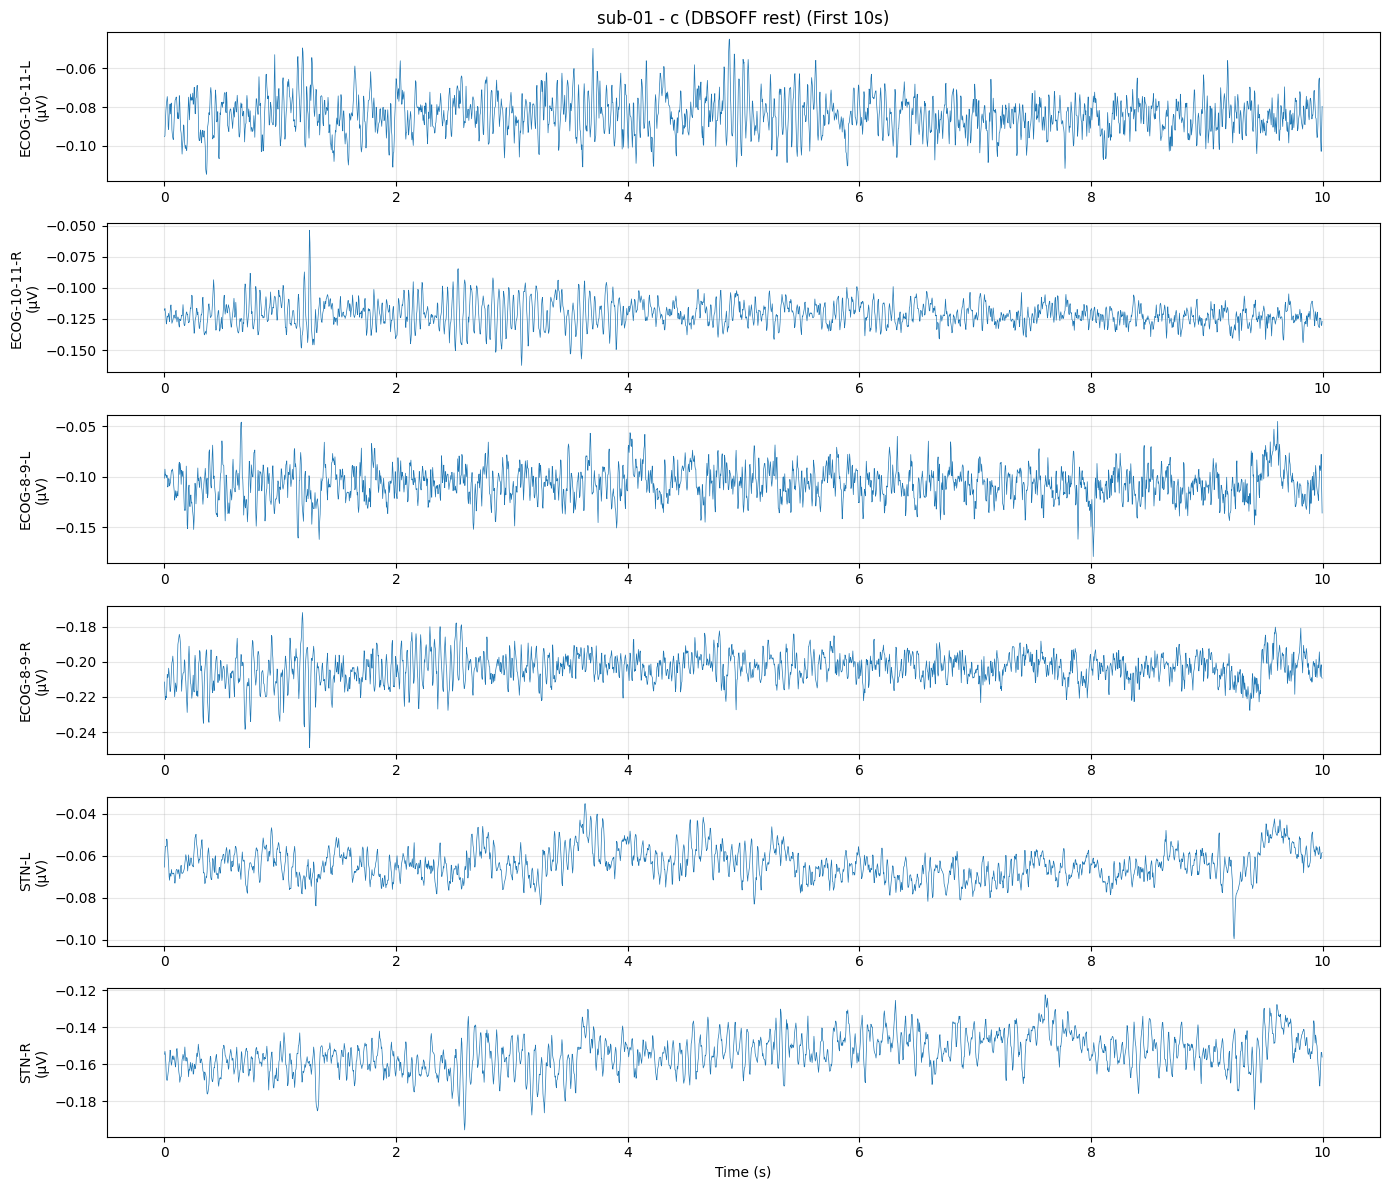

📊 Plotting PSD (0-50 Hz)...


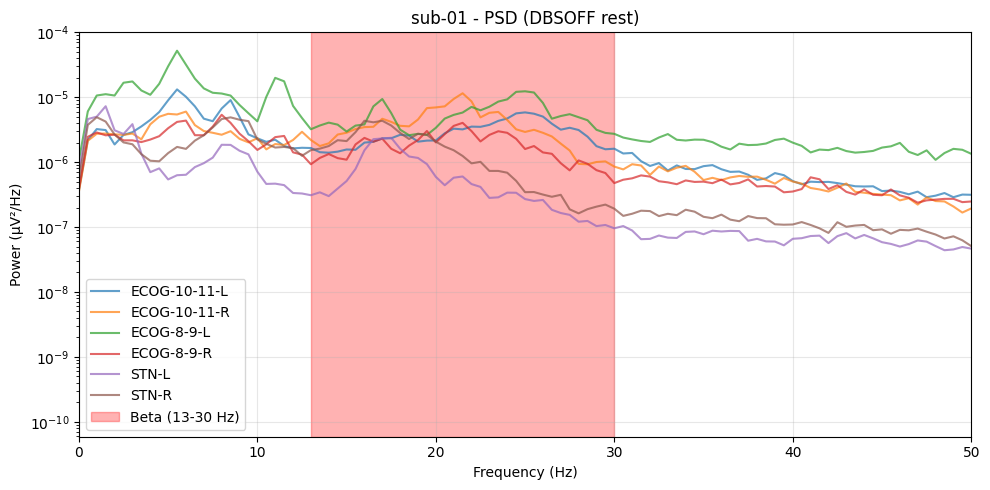


🔬 Beta power summary (13-30 Hz):
  ECOG-10-11-L: 2.900e-06 μV²/Hz
  ECOG-10-11-R: 3.903e-06 μV²/Hz
  ECOG-8-9-L  : 5.544e-06 μV²/Hz
  ECOG-8-9-R  : 1.834e-06 μV²/Hz
  STN-L       : 6.347e-07 μV²/Hz
  STN-R       : 1.515e-06 μV²/Hz

✅ Visualization complete
💡 To plot a different trial, edit TRIAL_FILE at the top of this script


In [ ]:
# visualize_ieeg_trial.py
"""
Load and visualize a single iEEG trial from derivatives/dbs/trials/
Uses imat.py plotting functions for consistency.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add imat.py to path
sys.path.append('/mnt/movement/users/jaizor/code/pd_ecog')
from imat import plot_raw_trace, plot_psd, _interpolate_nans
from scipy.signal import welch

# =============================================================================
# CONFIGURATION
# =============================================================================

TRIAL_FILE = Path('/mnt/movement/users/jaizor/xtra/derivatives/dbs/trials/rest_off/sub-01/rest_off_sub-01_c_ieeg.npz')
DURATION_SEC = 10  # Plot first 10 seconds
FMAX = 50          # Max frequency for PSD

# =============================================================================
# LOAD TRIAL DATA
# =============================================================================

def load_trial(filepath: Path) -> tuple:
    """Load trial .npz, return (channel_data_dict, metadata, error_str)."""
    try:
        npz = np.load(filepath, allow_pickle=True)
        
        # Extract metadata
        meta = npz['trial_metadata'].item() if npz['trial_metadata'].ndim == 0 else npz['trial_metadata']
        
        # Extract channel data (skip non-channel keys)
        channels = {}
        for key in npz.files:
            if key == 'trial_metadata':
                continue
            channels[key] = npz[key]
        
        return channels, meta, None
        
    except Exception as e:
        return None, None, str(e)

# =============================================================================
# PREPARE DATA FOR PLOTTING
# =============================================================================

def stack_channels(channels: dict, ch_order: list = None) -> tuple:
    """
    Stack channel dict into (n_channels × n_samples) array for plotting.
    
    Returns
    -------
    data : np.ndarray
        Stacked channel data
    ch_names : list
        Channel names in order
    sfreq : float
        Sampling frequency (from first channel's metadata if available)
    """
    if not channels:
        raise ValueError("No channels to plot")
    
    # Determine channel order
    if ch_order is None:
        ch_order = sorted(channels.keys())
    
    # Stack data
    data_list = [channels[ch] for ch in ch_order if ch in channels]
    if not data_list:
        raise ValueError("No valid channel data found")
    
    # All channels should have same length (same trial window)
    data = np.vstack(data_list)
    
    return data, ch_order, None  # sfreq comes from metadata

# =============================================================================
# MAIN VISUALIZATION
# =============================================================================

def visualize_trial(trial_path: Path, duration: float = 10, fmax: float = 50):
    """Load and plot raw trace + PSD for one iEEG trial."""
    
    print(f"\n🔍 Loading: {trial_path.name}")
    channels, meta, err = load_trial(trial_path)
    
    if err:
        print(f"❌ Load failed: {err}")
        return
    
    print(f"✓ Loaded {len(channels)} channels")
    print(f"  Subject: {meta['subject_id']}, Trial: {meta['trial_name']}")
    print(f"  Duration: {meta['duration_sec']:.1f}s, sfreq: {meta['sfreq']} Hz")
    print(f"  Channels: {meta['channels']}")
    
    # Stack channels for plotting
    data, ch_names, _ = stack_channels(channels)
    sfreq = meta['sfreq']
    
    # Plot raw trace (first N seconds)
    print(f"\n📈 Plotting raw trace (first {duration}s)...")
    plot_raw_trace(
        data, sfreq,
        title=f"{meta['subject_id']} - {meta['trial_name']} (DBSOFF rest)",
        duration=duration,
        ch_names=ch_names
    )
    
    # Plot PSD (full trial)
    print(f"📊 Plotting PSD (0-{fmax} Hz)...")
    plot_psd(
        data, sfreq,
        title=f"{meta['subject_id']} - PSD (DBSOFF rest)",
        ch_names=ch_names,
        fmax=fmax,
        interpolate_nans=True
    )
    
    # Optional: Print beta power summary
    print(f"\n🔬 Beta power summary (13-30 Hz):")
    for i, ch_name in enumerate(ch_names):
        ch_data = data[i]
        if np.any(np.isnan(ch_data)):
            ch_data = _interpolate_nans(ch_data)
        freqs, psd = welch(ch_data, sfreq, nperseg=sfreq*2, noverlap=sfreq)
        beta_mask = (freqs >= 13) & (freqs <= 30)
        beta_power = np.mean(psd[beta_mask])
        print(f"  {ch_name:12s}: {beta_power:.3e} μV²/Hz")

# =============================================================================
# RUN
# =============================================================================

if __name__ == '__main__':
    if not TRIAL_FILE.exists():
        print(f"❌ Trial file not found: {TRIAL_FILE}")
        print(f"\n💡 Try listing available trials:")
        print(f"   ls /mnt/movement/users/jaizor/xtra/derivatives/dbs/trials/rest_off/sub-*/")
        sys.exit(1)
    
    visualize_trial(TRIAL_FILE, duration=DURATION_SEC, fmax=FMAX)
    
    print(f"\n✅ Visualization complete")
    print(f"💡 To plot a different trial, edit TRIAL_FILE at the top of this script")